<a href="https://colab.research.google.com/github/SangatMaharjan/Machine-Learning-CSE/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing for Machine Learning

In [ ]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset provided in csv format

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)

In [ ]:
# Displaying the basic information

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Check missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


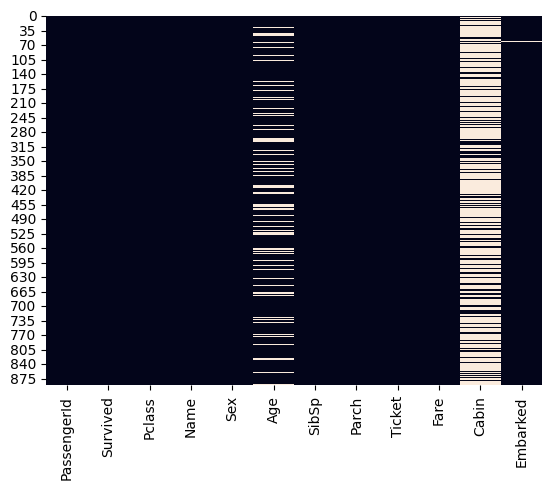

In [ ]:
# Visualizing the missing values in heatmap

sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [ ]:
# Fill missing age values with median

df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_6972/67711322.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
#Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_6972/3019082526.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [ ]:
# Drop Cabin Column

df.drop('Cabin',axis=1,inplace=True)

In [ ]:
# Identify categorical attributes

df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [ ]:
# Apply Label Encoding

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

In [ ]:
# Apply One - Hot Encoding

df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [ ]:
# Select numerical columns

num_cols=['Age','Fare']

In [ ]:
# Apply Standardization

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])


In [ ]:
# Observe transformed values

df[['Age','Fare']].head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


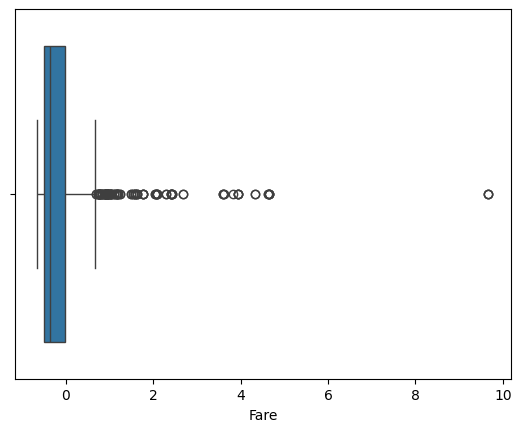

In [ ]:
# Draw Boxplot

sns.boxplot(x=df['Fare'])
plt.show()

In [ ]:
# Calculate Inner Quartile Range

Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3 +1.5 * IQR



In [ ]:
# Find outliers

outliers = df[(df['Fare']<lower)| (df['Fare']>upper)]
print(len(outliers))

116


In [ ]:
# Remove unnecessary columns

df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [ ]:
# Seperate features and target

x= df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
# Check final shape

print(x.shape)
print(y.shape)

(891, 8)
(891,)


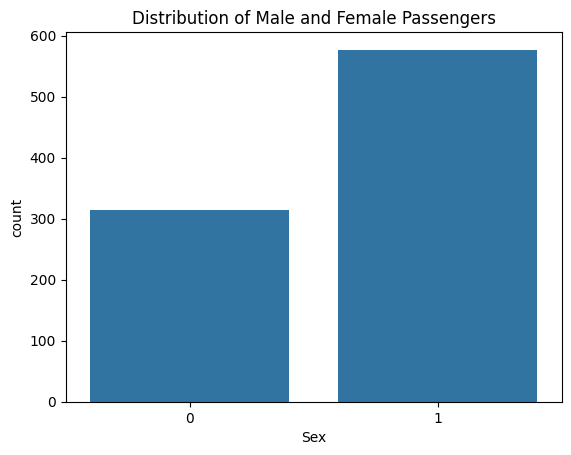

In [ ]:
# Count the number of male and female passengers
 # Since we have encoded , the x - axis will show 0 and 1
sns.countplot(data=df, x='Sex')
plt.title('Distribution of Male and Female Passengers')
plt.show()


In [ ]:
# Calculate average age before and after filling missing values

df_original=pd.read_csv(url)
average_age_before=df_original['Age'].mean()

average_age_after=df['Age'].mean()

print("Average Age Before : ", average_age_before)
print("Average Age After : ",average_age_after)

Average Age Before :  29.69911764705882
Average Age After :  2.272779794518839e-16


In [ ]:
# Detect outliers in the Age Column

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]

print(f"Total Outliers : {len(outliers)}")
print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")

Total Outliers : 248
Lower Bound : -1.18650103391317
Upper Bound : 0.6731064591401562


In [ ]:
# Apply Min - Max Scaling instead of Standardization

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])


